<a href="https://colab.research.google.com/github/Parixxx21/ECE219-Project3/blob/temp/219pset3partc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question21

Mounted at /content/drive
Shape: (149871, 14)

Columns:
['color', 'clarity', 'carat', 'cut', 'symmetry', 'polish', 'depth_percent', 'table_percent', 'length', 'width', 'depth', 'girdle_min', 'girdle_max', 'price']

Data types:
color             object
clarity           object
carat            float64
cut               object
symmetry          object
polish            object
depth_percent    float64
table_percent    float64
length           float64
width            float64
depth            float64
girdle_min        object
girdle_max        object
price              int64
dtype: object

Numerical columns: ['carat', 'depth_percent', 'table_percent', 'length', 'width', 'depth', 'price']
Categorical columns: ['color', 'clarity', 'cut', 'symmetry', 'polish', 'girdle_min', 'girdle_max']


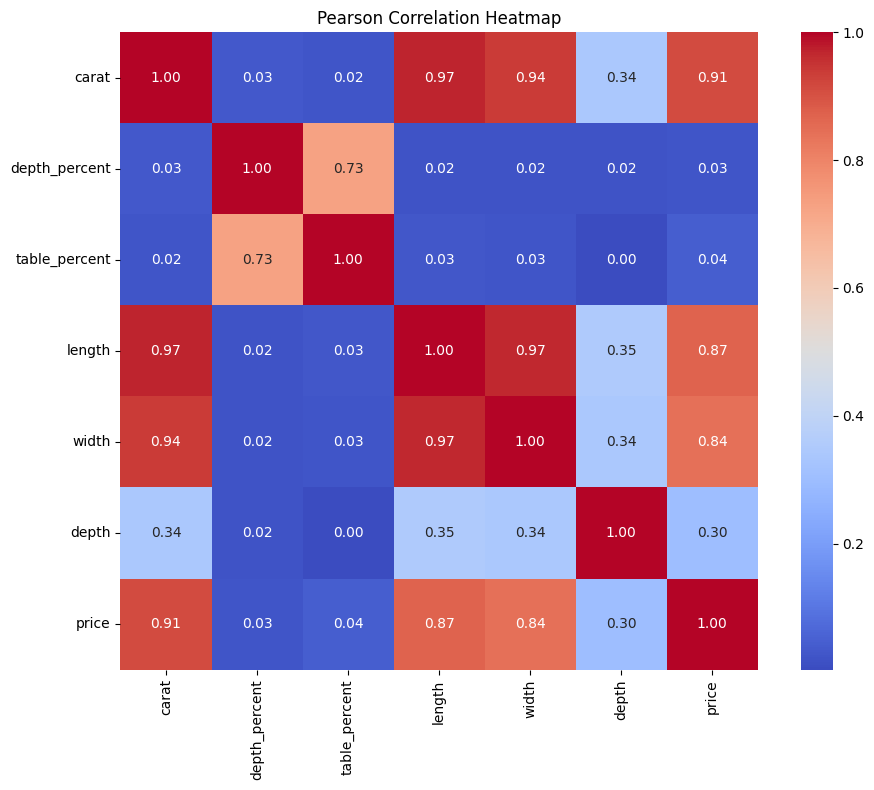


Absolute correlations with price:
carat            0.913479
length           0.869521
width            0.841887
depth            0.299696
table_percent    0.042453
depth_percent    0.025469
Name: price, dtype: float64

Top features most correlated with price:
carat            0.913479
length           0.869521
width            0.841887
depth            0.299696
table_percent    0.042453
Name: price, dtype: float64


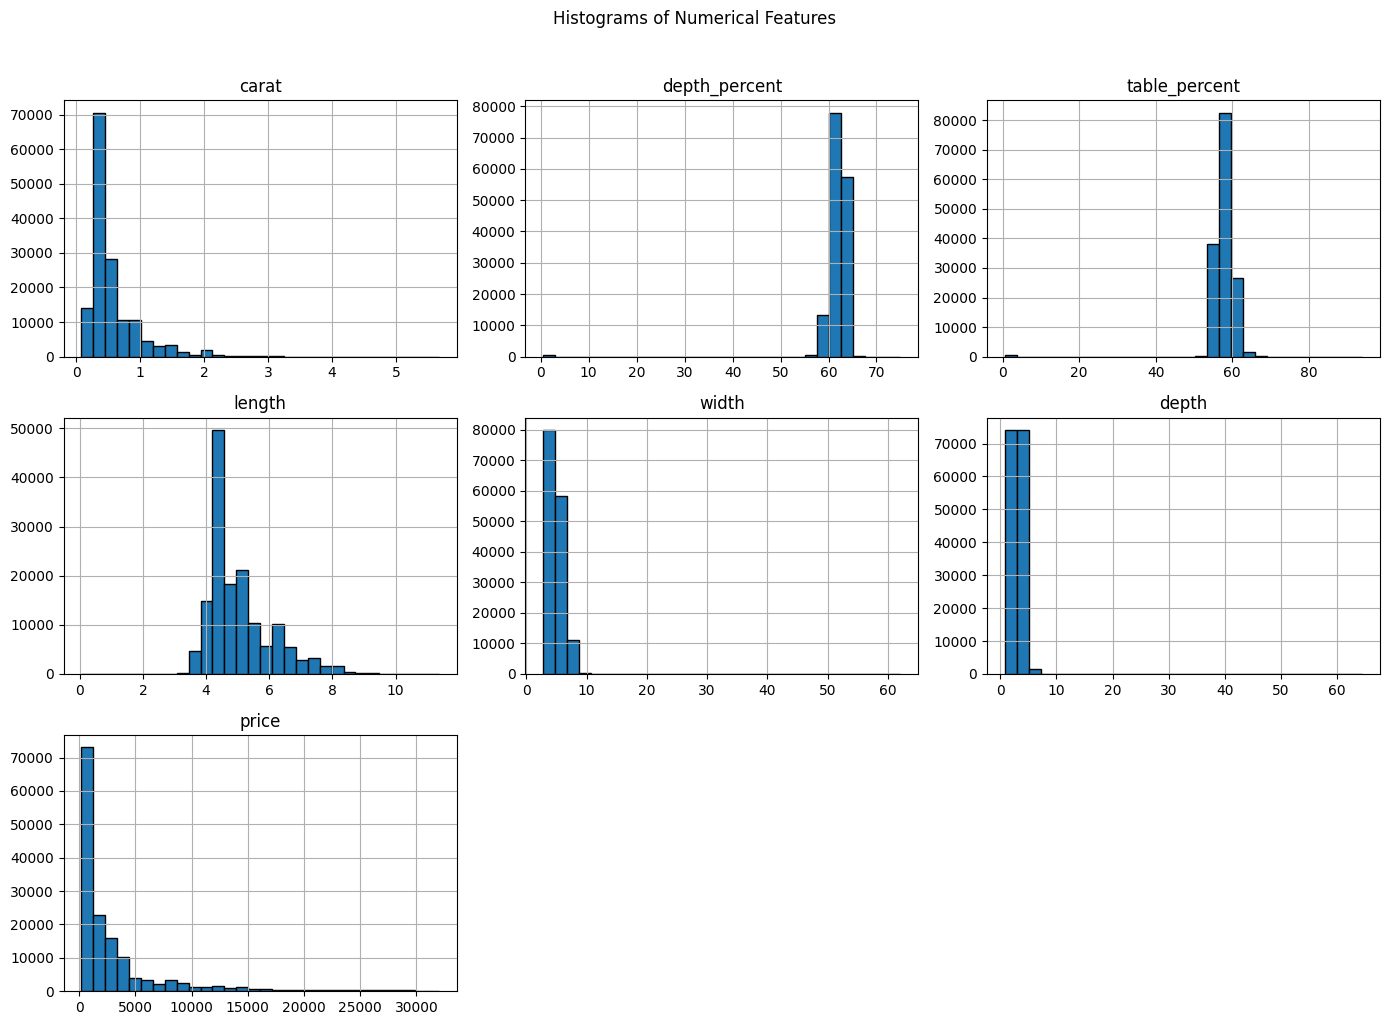


Skewness of numerical features:
depth            27.493299
depth_percent   -13.559608
table_percent   -11.046563
width             4.115348
price             3.071737
carat             2.331773
length            1.283604
dtype: float64

Highly skewed features (|skew| > 1):
depth            27.493299
depth_percent   -13.559608
table_percent   -11.046563
width             4.115348
price             3.071737
carat             2.331773
length            1.283604
dtype: float64

Suggested transformation:
- depth: apply log1p transformation -> np.log1p(df['depth'])
- depth_percent: apply log1p transformation -> np.log1p(df['depth_percent'])
- table_percent: apply log1p transformation -> np.log1p(df['table_percent'])
- width: apply log1p transformation -> np.log1p(df['width'])
- price: apply log1p transformation -> np.log1p(df['price'])
- carat: apply log1p transformation -> np.log1p(df['carat'])
- length: apply log1p transformation -> np.log1p(df['length'])


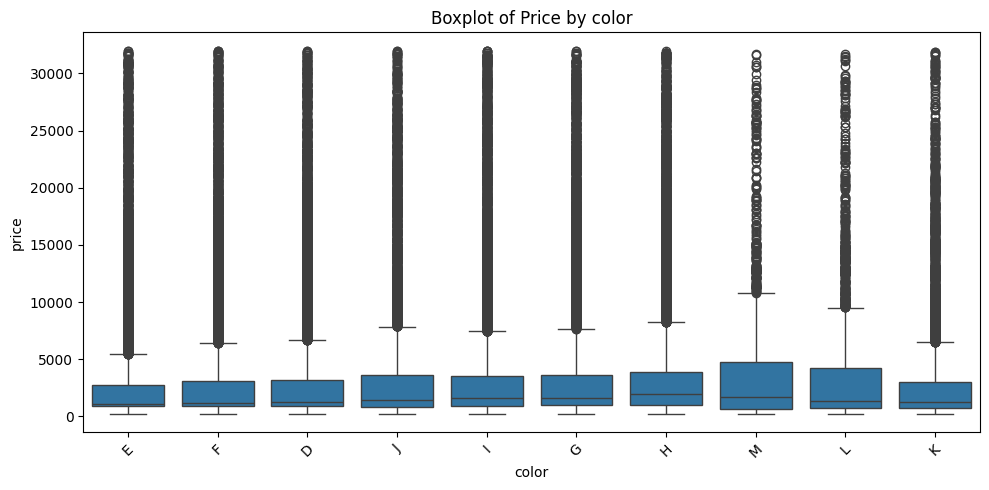


Median price by color:
color
H    1929.0
M    1724.0
I    1656.0
G    1584.0
J    1462.0
L    1373.0
D    1256.0
K    1246.0
F    1156.0
E    1080.0
Name: price, dtype: float64


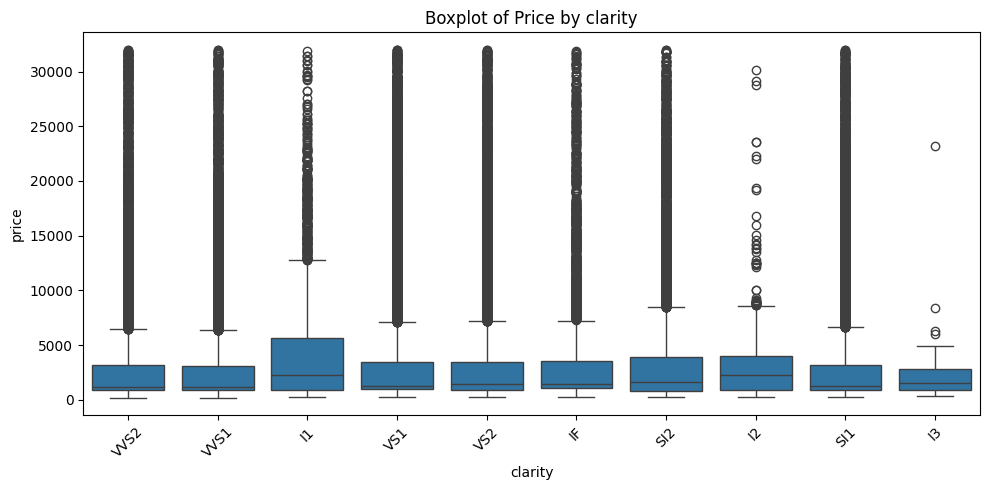


Median price by clarity:
clarity
I1      2276.0
I2      2262.0
SI2     1596.0
I3      1520.0
IF      1404.0
VS2     1392.0
VS1     1274.0
SI1     1230.0
VVS1    1196.0
VVS2    1176.0
Name: price, dtype: float64


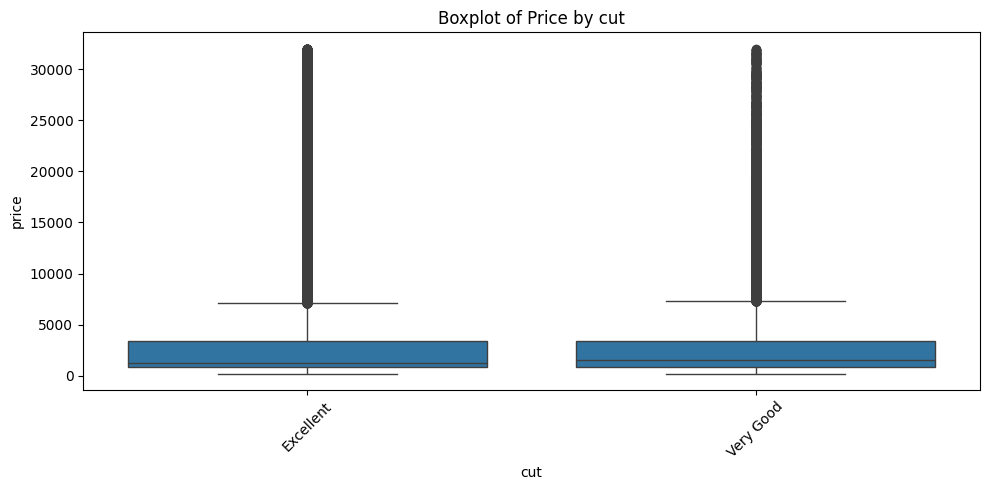


Median price by cut:
cut
Very Good    1542.0
Excellent    1260.0
Name: price, dtype: float64


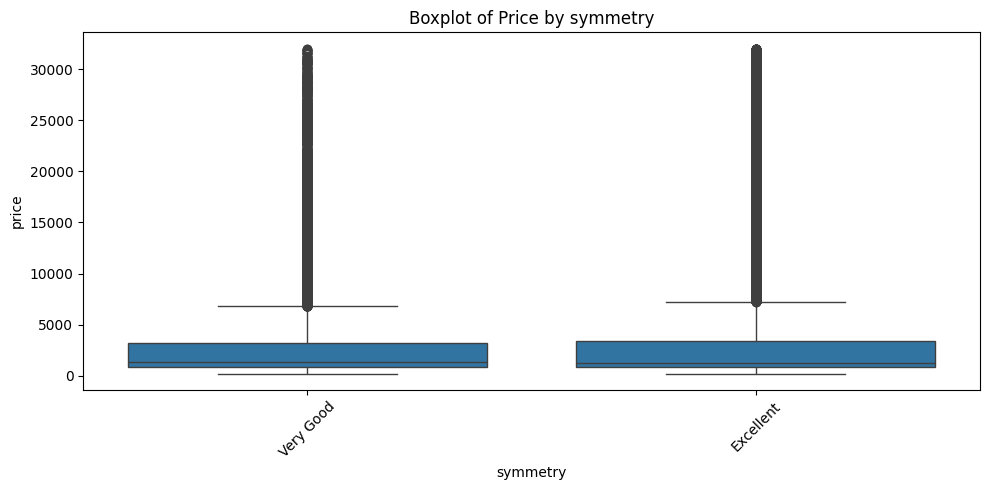


Median price by symmetry:
symmetry
Very Good    1380.0
Excellent    1286.0
Name: price, dtype: float64


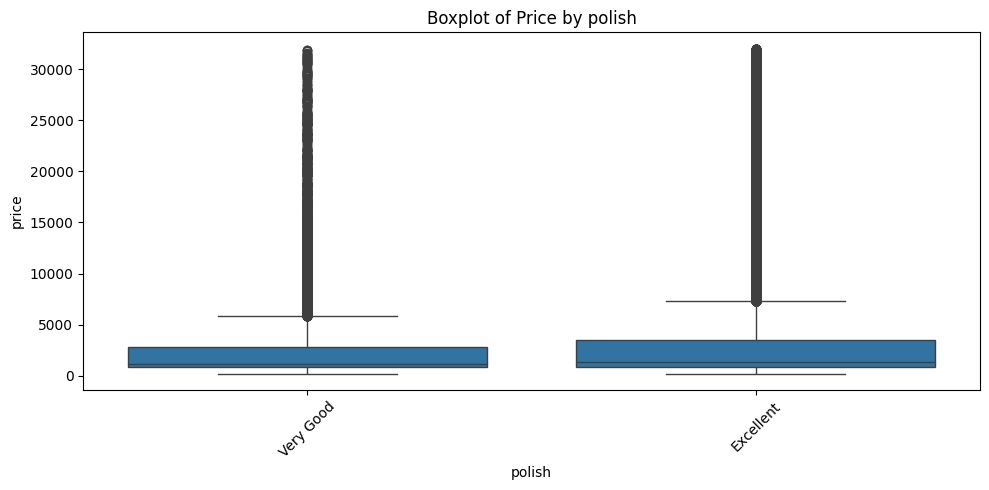


Median price by polish:
polish
Excellent    1330.0
Very Good    1126.0
Name: price, dtype: float64


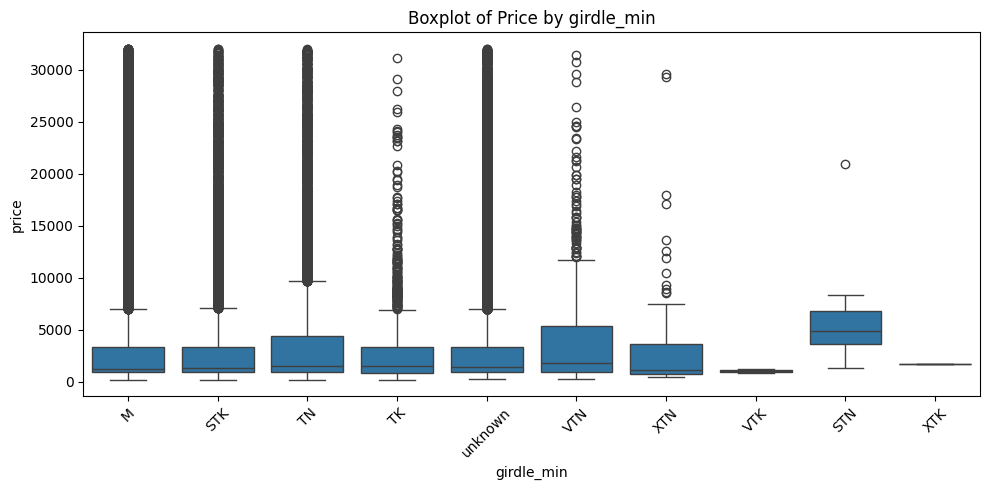


Median price by girdle_min:
girdle_min
STN        4906.0
VTN        1822.0
XTK        1684.0
TN         1548.0
TK         1475.0
unknown    1418.0
STK        1302.0
M          1216.0
XTN        1080.0
VTK        1019.0
Name: price, dtype: float64


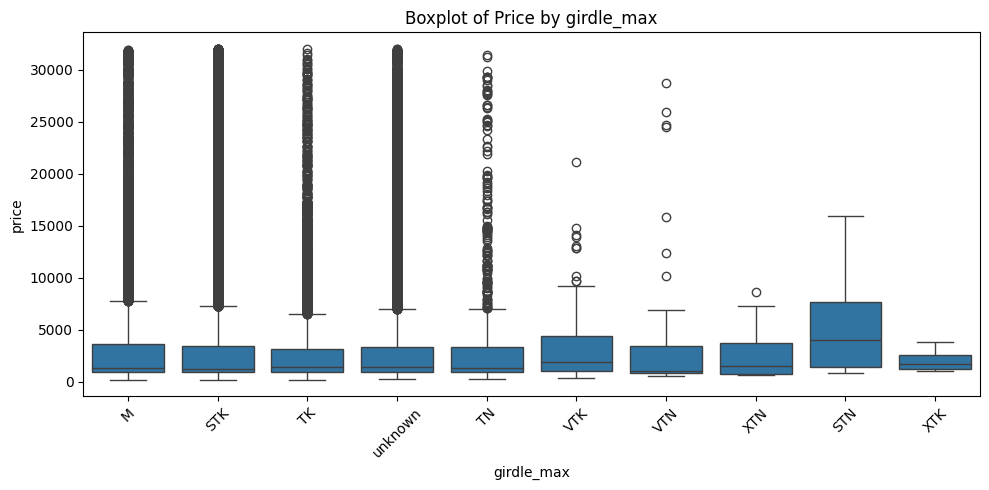


Median price by girdle_max:
girdle_max
STN        3997.0
VTK        1850.0
XTK        1684.0
XTN        1497.0
unknown    1438.0
TK         1384.0
TN         1350.0
M          1304.0
STK        1228.0
VTN        1015.0
Name: price, dtype: float64

===== EDA Summary =====

Top correlations with price:
carat            0.913479
length           0.869521
width            0.841887
depth            0.299696
table_percent    0.042453
Name: price, dtype: float64

Highly skewed numerical features:
depth            27.493299
depth_percent   -13.559608
table_percent   -11.046563
width             4.115348
price             3.071737
carat             2.331773
length            1.283604
dtype: float64

Top median prices by color:
color
H    1929.0
M    1724.0
I    1656.0
G    1584.0
J    1462.0
Name: price, dtype: float64

Top median prices by clarity:
clarity
I1     2276.0
I2     2262.0
SI2    1596.0
I3     1520.0
IF     1404.0
Name: price, dtype: float64

Top median prices by cut:
cut
Very Good

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diamonds_ece219.csv')
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


corr = df[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

# Correlation with target variable price
if "price" in corr.columns:
    price_corr = corr["price"].drop("price").sort_values(key=lambda x: abs(x), ascending=False)
    print("\nAbsolute correlations with price:")
    print(price_corr)

    print("\nTop features most correlated with price:")
    print(price_corr.head(5))


# Histograms for numerical features
df[num_cols].hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Histograms of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

# Skewness
skewness = df[num_cols].skew().sort_values(key=lambda x: abs(x), ascending=False)
print("\nSkewness of numerical features:")
print(skewness)

# Identify highly skewed features
high_skew = skewness[abs(skewness) > 1]
print("\nHighly skewed features (|skew| > 1):")
print(high_skew)

print("\nSuggested transformation:")
for col in high_skew.index:
    if (df[col] > 0).all():
        print(f"- {col}: apply log1p transformation -> np.log1p(df['{col}'])")
    else:
        print(f"- {col}: consider Yeo-Johnson or Box-Cox after handling non-positive values")

# -----------------------------
# 5. Categorical Analysis
# -----------------------------
# Boxplots of categorical features vs price
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y="price")
    plt.title(f"Boxplot of Price by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Also print median price per category for easier interpretation
    median_price = df.groupby(col)["price"].median().sort_values(ascending=False)
    print(f"\nMedian price by {col}:")
    print(median_price)

# -----------------------------
# 6. Optional: concise summary output
# -----------------------------
print("\n===== EDA Summary =====")

if "price" in corr.columns:
    print("\nTop correlations with price:")
    print(price_corr.head(5))

print("\nHighly skewed numerical features:")
print(high_skew)

for col in cat_cols:
    print(f"\nTop median prices by {col}:")
    print(df.groupby(col)["price"].median().sort_values(ascending=False).head())

Carat has the highest absolute correlation with the target variable (0.91), indicating that the weight (size) of the diamond is the most important factor affecting its price.The physical dimensions length and width also show strong positive correlations with price because larger diamonds typically have larger measurements.

Other features such as depth, table_percent, and depth_percent have much weaker correlations with price, suggesting that these proportions of the diamond have a smaller direct influence on pricing compared to overall size.

The histogram shows price, carat, length and width are highly right skewed. A log transformation is recommended to preprocess it.

Box plots of the categorical features against price show several noticeable trends. Diamonds with higher quality cut grades tend to have slightly higher median prices. For color, diamonds with better color grades generally exhibit higher median prices compared to lower grades, indicating that color quality contributes to diamond value. Similarly, diamonds with higher clarity levels tend to have higher median prices than those with lower clarity. However, the substantial overlap in price distributions across these categories suggests that while cut, color, and clarity influence pricing, they are not the dominant factors; other features such as diamond size likely play a more significant role in determining price.

## Question22

For all the features except girdle, ordinal encoding was applied because the categories represent an inherent ranking in quality. Using ordinal encoding preserves this natural ordering and allows the model to capture the relative quality differences between categories. For girdle, we use one hot encoding because their categories do not represent a strict ordinal scale. One-hot encoding avoids introducing artificial ordering assumptions between thickness categories

One-hot encoding discards any ordering or similarity information between categories, since each category is treated as completely independent.

If scalar encoding is used, it assumes that the categories have a meaningful and consistent order, and that the assigned numbers correctly represent their ranking.

## Question 23

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diamonds_ece219.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

cut_order = ['Fair','Good','Very Good','Premium','Excellent']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
quality_order = ['Poor','Fair','Good','Very Good','Excellent','Ideal']

df['cut'] = df['cut'].map({v:i for i,v in enumerate(cut_order)})
df['color'] = df['color'].map({v:i for i,v in enumerate(color_order)})
df['clarity'] = df['clarity'].map({v:i for i,v in enumerate(clarity_order)})
df['symmetry'] = df['symmetry'].map({v:i for i,v in enumerate(quality_order)})
df['polish'] = df['polish'].map({v:i for i,v in enumerate(quality_order)})

df = pd.get_dummies(df, columns=['girdle_min','girdle_max'])

X = df.drop(columns=['price'])
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

df_standardized = pd.concat([X_scaled, y], axis=1)

df_standardized.to_csv("/content/drive/MyDrive/Colab Notebooks/diamonds_standardized.csv", index=False)


Mounted at /content/drive


## Question 24

In [ ]:
import json
import re
import io
import os
import contextlib
import traceback
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import scipy.stats as stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks")
TABLE_DIR = DATA_DIR

q_path = DATA_DIR / "diamonds-questions.jsonl"
l_path = DATA_DIR / "diamonds-labels.jsonl"

def load_jsonl(path: Path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

questions = load_jsonl(q_path)
labels = load_jsonl(l_path)

q_by_id = {q["id"]: q for q in questions}
l_by_id = {l["id"]: l for l in labels}

print("num questions =", len(questions))
print("num labels =", len(labels))
print("Q0:", q_by_id[0])
print("Q1:", q_by_id[1])

num questions = 5
num labels = 5
Q0: {'id': 0, 'question': "Compute Mutual Information scores for all features against the target variable 'price' using sklearn.feature_selection.mutual_info_regression. Return the top 5 feature names ranked from highest to lowest MI score.", 'concepts': ['Feature Selection', 'Mutual Information'], 'constraints': "Use sklearn.feature_selection.mutual_info_regression. Features are all columns except 'price'. Target is 'price'. Use random_state=42.", 'format': '@top5_mi[name1, name2, name3, name4, name5] where names are the feature column names ranked from highest to lowest MI score.', 'file_name': 'diamonds_standardized.csv', 'level': 'medium'}
Q1: {'id': 1, 'question': "Compute F-regression scores for all features against the target variable 'price' using sklearn.feature_selection.f_regression. Return the top 5 feature names ranked from highest to lowest F-score.", 'concepts': ['Feature Selection', 'F-regression'], 'constraints': "Use sklearn.feature_se

In [ ]:
from huggingface_hub import login

HF_TOKEN = "YOUR TOKEN HERE"
login(HF_TOKEN)

In [ ]:
!pip install -q transformers accelerate pydantic torch outlines
!pip install -q trl peft accelerate bitsandbytes
!pip install -q transformers datasets
!pip -q install llguidance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.3 MB/s eta 0:00:00


In [ ]:
import json
import torch
from pydantic import BaseModel
from transformers import AutoTokenizer, AutoModelForCausalLM
import outlines
import importlib

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=dtype,
)
planner_model = outlines.models.Transformers(hf_model, tokenizer)

class PlannerOutput(BaseModel):
    thought: str
    is_done: bool
    response: str

PLANNER_SYSTEM = """You are the PLANNER for a data-mining agent.
Output ONLY ONE JSON object with EXACT keys: thought, is_done, response.
No other text.

Rules:
- STRICT JSON using double quotes only.
- No markdown, no extra text.
- End with a closing brace: }
Template:
{"thought":"...","is_done":false,"response":"..."}
"""

# Minimal JSON Schema compatible with Outlines-core regex compiler
minimal_schema = {
    "type": "object",
    "additionalProperties": False,
    "required": ["thought", "is_done", "response"],
    "properties": {
        "thought": {"type": "string"},
        "is_done": {"type": "boolean"},
        "response": {"type": "string"},
    },
}
schema_str = json.dumps(minimal_schema)

og = importlib.import_module("outlines.generator")
term = og.JsonSchema(schema_str)

planner_gen = og.Generator(planner_model, term, None)

def run_planner(user_prompt: str, max_new_tokens: int = 512) -> str:
    prompt = f"{PLANNER_SYSTEM}\n\nUSER:\n{user_prompt}"
    return planner_gen(prompt, max_new_tokens=max_new_tokens)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
def resolve_path(file_name: str) -> str:
    return str((TABLE_DIR / file_name).resolve())

@dataclass
class ExecResult:
    ok: bool
    stdout: str
    stderr: str
    tb: str

@dataclass
class Observation:
    status: str
    summary: str
    data: dict

def execute_python(code: str, extra_globals: dict | None = None) -> ExecResult:
    g = {
        "__name__": "__main__",
        "pd": pd,
        "np": np,
        "re": re,
        "json": json,
        "os": os,
        "stats": stats,
        "resolve_path": resolve_path,
        "TABLE_DIR": TABLE_DIR,
        "DATA_DIR": DATA_DIR,
    }
    if extra_globals:
        g.update(extra_globals)

    stdout_buf, stderr_buf = io.StringIO(), io.StringIO()
    try:
        with contextlib.redirect_stdout(stdout_buf), contextlib.redirect_stderr(stderr_buf):
            exec(code, g, g)
        return ExecResult(True, stdout_buf.getvalue(), stderr_buf.getvalue(), "")
    except Exception:
        return ExecResult(False, stdout_buf.getvalue(), stderr_buf.getvalue(), traceback.format_exc())

def observe(exec_res: ExecResult, max_chars: int = 1200) -> Observation:
    if not exec_res.ok:
        tail = (exec_res.tb or "")[-max_chars:]
        return Observation(status="error", summary=tail, data={"ok": False, "error": tail})

    out = (exec_res.stdout or "").strip()
    data = {}
    if out:
        last_line = out.splitlines()[-1].strip()
        if last_line.startswith("{") and last_line.endswith("}"):
            try:
                data = json.loads(last_line)
            except Exception:
                data = {}

    return Observation(status="ok", summary=out[-max_chars:], data=data)

def compact_history(history, keep_last=3):
    recent = history[-keep_last:]
    lines = []
    for h in recent:
        lines.append(f"Step {h['step']}")
        lines.append(f"Planner: {h['planner_response']}")
        lines.append(f"Observation: {h['obs'].summary[:300]}")
    return "\n".join(lines) if lines else "(none)"

In [ ]:
import importlib
import outlines
from pydantic import BaseModel

class PlannerOutput(BaseModel):
    thought: str
    is_done: bool
    response: str

PLANNER_SYSTEM = """You are the PLANNER for a data-mining ReAct agent.

You must output ONLY ONE JSON object with EXACT keys: thought, is_done, response.
No other text.

Rules:
- STRICT JSON only (double quotes).
- If finished, set is_done=true and response MUST be the final formatted answer exactly matching the question's format.
- Otherwise set is_done=false and response MUST be a single actionable instruction for the Coder.
- When is_done=true, response MUST contain ONLY the final formatted answer(s). No extra text.
- IMPORTANT: If the latest observation includes parsed JSON like {"ok": true, "values": {...}},
  then use values to produce the final response in the required slot format, e.g. @mean_fare[34.65].
Template:
{"thought":"...","is_done":false,"response":"..."}
"""

# Minimal JSON schema that Outlines-core supports
minimal_schema = {
    "type": "object",
    "additionalProperties": False,
    "required": ["thought", "is_done", "response"],
    "properties": {
        "thought": {"type": "string"},
        "is_done": {"type": "boolean"},
        "response": {"type": "string"},
    },
}
schema_str = json.dumps(minimal_schema)

og = importlib.import_module("outlines.generator")
term = og.JsonSchema(schema_str)

# planner_model must exist (Outlines wrapper around hf_model)
# planner_model = outlines.models.Transformers(hf_model, tokenizer)
planner_gen = og.Generator(planner_model, term, None)

def run_planner(prompt: str, max_new_tokens: int = 384) -> PlannerOutput:
    # Try a few times; if the model truncates, re-sample.
    last_err = None
    for _ in range(5):
        j = planner_gen(prompt, max_new_tokens=max_new_tokens)
        j = (j or "").strip()

        # common fix: model outputs valid JSON prefix then truncates
        if "}" in j:
            j2 = j[: j.rfind("}") + 1]
        else:
            j2 = j

        try:
            return PlannerOutput.model_validate_json(j2)
        except Exception as e:
            last_err = e

    # If still failing, raise a helpful error showing tail
    tail = (j or "")[-300:]
    raise RuntimeError(f"Planner produced invalid JSON repeatedly. Tail:\n{tail}\n\nLast error: {last_err}")

In [ ]:
import torch

def hf_generate_text(prompt: str, max_new_tokens: int = 512) -> str:
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(hf_model.device) for k, v in inputs.items()}
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        out = hf_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    # decode only the generated continuation (not the prompt)
    gen_ids = out[0, prompt_len:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

def extract_code(text: str) -> str:
    # If model emits ```python ...```, extract; else return full text.
    m = re.search(r"```(?:python)?\s*(.*?)```", text, flags=re.DOTALL|re.IGNORECASE)
    if m:
        return m.group(1).strip()
    return text.strip()

CODER_SYSTEM = """You are the CODER for a data analysis agent.
Write ONLY Python code (no markdown/backticks/explanations).

HARD REQUIREMENTS:
- DO NOT define or overwrite: resolve_path, TABLE_DIR, DATA_DIR.
- DO NOT use os.getcwd() or relative paths to locate files.
- Always: import json
- Always load the CSV using EXACTLY:
    df = pd.read_csv(resolve_path(file_name))
- Always print EXACTLY ONE final line using:
    print(json.dumps(obj))
- obj must be one of:
  {"ok": True, "values": {...}} OR {"ok": False, "error": "..."}
- IMPORTANT: keys inside values must be plain slot names with NO '@' and NO brackets.
  Example: {"ok": True, "values": {"mean_fare": 34.65}}
- Catch ALL exceptions and print {"ok": False, "error": "..."} using json.dumps.
- Never print anything after the final json.dumps line.

DATA/STAT RULES:
- NEVER use np.skew or np.kurtosis (they do not exist).
- Use ONE of:
  * pandas Series: s.skew(), s.kurt()
  * scipy.stats: stats.skew(s), stats.kurtosis(s, fisher=True, bias=False), stats.shapiro(s)
- If the target column is ambiguous, inspect df.columns and choose the best match by case-insensitive substring (e.g., "case" for cases, "bmi" for BMI).
- For "normal vs not_normal" distribution questions:
  Use Shapiro-Wilk on cleaned numeric series (dropna).
  If p_value >= 0.05 -> "normal" else "not_normal",
  unless constraints specify a different rule (follow constraints).
- For questions like "mean number of cases recorded across all countries and years" (estimated_numbers.csv):
    - Prefer a column that contains BOTH "case" and "median" (case-insensitive), e.g. "No. of cases_median".
    - Else, use a column containing "No. of cases".
      If values look like "N[low-high]", extract the leading integer N via regex r"^\s*(\d+)".
    - Convert to numeric with pd.to_numeric(errors="coerce"), drop NaNs, compute mean.
    - Return int(mean) (truncate).
"""

def run_coder(question: dict, planner_instruction: str, history_str: str, max_new_tokens: int = 700) -> str:
    file_name = question.get("file_name", "")

    # ---- dataset-specific hint (by filename, not by question id) ----
    extra_hint = ""
    if file_name == "estimated_numbers.csv" and "mean_cases" in question.get("format", ""):
        extra_hint = """
DATASET NOTE (estimated_numbers.csv):
- This file has columns like: "No. of cases", "No. of cases_median", "No. of cases_min", "No. of cases_max".
- For mean_cases, PREFER "No. of cases_median" if present.
- If using "No. of cases" and values look like "N[low-high]", extract the leading integer N via regex r"^\\s*(\\d+)".
- Convert with pd.to_numeric(errors="coerce"), dropna, then mean, then int(mean) (truncate).
"""

    prompt = f"""{CODER_SYSTEM}

You have access to resolve_path(file_name).

Set:
file_name = {repr(file_name)}

QUESTION:
{question.get('question','')}

CONSTRAINTS:
{question.get('constraints','')}

REQUIRED FORMAT:
{question.get('format','')}

PLANNER INSTRUCTION:
{planner_instruction}

RECENT HISTORY:
{history_str}
{extra_hint}
Write Python now.
"""
    gen = hf_generate_text(prompt, max_new_tokens=max_new_tokens)
    return extract_code(gen)

<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1423/2867008803.py:58: SyntaxWarning: invalid escape sequence '\s'
  If values look like "N[low-high]", extract the leading integer N via regex r"^\s*(\d+)".


In [ ]:
def extract_code(text: str) -> str:
    m = re.search(r"```(?:python)?\s*(.*?)```", text, flags=re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()
    return text.strip()

FEATURE_CODER_SYSTEM = """You are the CODER for a ReAct data analysis agent.
Write ONLY Python code. No markdown, no backticks, no explanations.

Task:
- Load the diamonds dataset referenced by the question.
- Identify the target column as 'price'.
- Use all other columns as candidate features.
- Convert categorical columns to numeric appropriately.
- Compute top 5 features using:
  1) mutual_info_regression
  2) f_regression
- Print EXACTLY ONE final JSON object using json.dumps.

Required JSON format:
{
  "ok": true,
  "values": {
    "mutual_info_top5": [...],
    "f_regression_top5": [...]
  }
}

Rules:
- Always: import json
- You MUST load the CSV using:
    df = pd.read_csv(resolve_path(file_name))
- Do NOT define, mock, or overwrite resolve_path.
- Do NOT hard-code paths like './data/...'
- Handle categorical columns safely.
- Drop rows with missing target if needed.
- Never print anything after the final json.dumps line.
- Catch exceptions and print:
    {"ok": false, "error": "..."}
"""

In [ ]:
def run_feature_coder(question: dict, planner_instruction: str, history_str: str = "", max_new_tokens: int = 900):
    file_name = question.get("file_name", "")

    prompt = f"""{FEATURE_CODER_SYSTEM}

You have access to resolve_path(file_name).

file_name = {repr(file_name)}

QUESTION:
{question.get('question', '')}

CONSTRAINTS:
{question.get('constraints', '')}

REQUIRED FORMAT:
{question.get('format', '')}

PLANNER INSTRUCTION:
{planner_instruction}

RECENT HISTORY:
{history_str}

Write Python now.
"""
    raw = hf_generate_text(prompt, max_new_tokens=max_new_tokens)
    return extract_code(raw)

In [ ]:
import re

def sanitize_agent_code(code: str) -> str:
    code = re.sub(r"^\s*```(?:python)?\s*$", "", code, flags=re.MULTILINE)


    code = re.sub(r"\btrue\b", "True", code)
    code = re.sub(r"\bfalse\b", "False", code)
    code = re.sub(r"\bnull\b", "None", code)

    return code

In [ ]:
def react_feature_selection(question: dict, max_steps: int = 3, verbose: bool = True):
    history = []

    for step in range(1, max_steps + 1):
        planner_prompt = f"""
You are the PLANNER for a ReAct data analysis agent.

Return ONLY one JSON object with keys:
- thought
- is_done
- response

Question:
{question.get('question', '')}

Constraints:
{question.get('constraints', '')}

Required format:
{question.get('format', '')}

History:
{compact_history(history)}

Rules:
- If no computation has been done yet, set is_done=false and tell the coder to compute top 5 features using mutual_info_regression and f_regression.
- If the latest observation contains JSON values for mutual_info_top5 and f_regression_top5, set is_done=true and summarize them clearly.
"""

        p = run_planner(planner_prompt, max_new_tokens=300)

        if verbose:
            print(f"\n=== STEP {step} PLANNER ===")
            print(p)

        if p.is_done:
            return p.response, history

        code = run_feature_coder(question, p.response, compact_history(history))

        if verbose:
            print(f"\n=== STEP {step} CODE ===")
            print(code)
        code = sanitize_agent_code(code)
        exec_res = execute_python(code)
        obs = observe(exec_res)

        if verbose:
            print(f"\n=== STEP {step} OBSERVATION ===")
            print(obs.summary)

        history.append({
            "step": step,
            "planner_response": p.response,
            "code": code,
            "obs": obs
        })

        if obs.data.get("ok") is True:
            vals = obs.data.get("values", {})
            final_text = (
                f"mutual_info top 5: {vals.get('mutual_info_top5', [])}\n"
                f"f_regression top 5: {vals.get('f_regression_top5', [])}"
            )
            return final_text, history

    return "Agent stopped without final answer.", history

In [ ]:
for qid in [0, 1]:
    print("\n" + "=" * 100)
    print(f"QUESTION ID: {qid}")
    print("Question text:", q_by_id[qid]["question"])
    print("Referenced file:", q_by_id[qid]["file_name"])

    final_answer, hist = react_feature_selection(q_by_id[qid], verbose=True)

    print("\nFINAL ANSWER:")
    print(final_answer)


QUESTION ID: 0
Question text: Compute Mutual Information scores for all features against the target variable 'price' using sklearn.feature_selection.mutual_info_regression. Return the top 5 feature names ranked from highest to lowest MI score.
Referenced file: diamonds_standardized.csv

=== STEP 1 PLANNER ===
thought="No computation has been done yet. I need to compute the Mutual Information scores for all features against the target variable 'price' using sklearn.feature_selection.mutual_info_regression." is_done=False response='Compute mutual information scores using mutual_info_regression with random_state=42. Extract the top 5 features ranked by MI score from highest to lowest.'

=== STEP 1 CODE ===
import json
import pandas as pd
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.preprocessing import LabelEncoder

file_name = 'diamonds_standardized.csv'
try:
    df = pd.read_csv(resolve_path(file_name))
except Exception as e:
    print(json.du

Mutual Information (mutual_info_regression) Top 5 features
['carat', 'width', 'length', 'depth', 'color']

F-regression (f_regression) Top 5 features
['carat', 'length', 'width', 'depth', 'polish']

In [ ]:
import pandas as pd

df = pd.read_csv(resolve_path("diamonds_standardized.csv"))

mi_top5 = ['carat', 'width', 'length', 'depth', 'color']
f_top5  = ['carat', 'length', 'width', 'depth', 'polish']

selected_features = sorted(set(mi_top5) | set(f_top5))
cols_to_save = selected_features + ["price"]

df_selected = df[cols_to_save].copy()

out_path = resolve_path("diamonds_selected.csv")
df_selected.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Columns:", cols_to_save)
print(df_selected.shape)

Saved: /content/drive/MyDrive/Colab Notebooks/diamonds_selected.csv
Columns: ['carat', 'color', 'depth', 'length', 'polish', 'width', 'price']
(149871, 7)


## Question 25

the agent got stuck, I manually write the code instead

In [ ]:
TARGET_IDS = [2, 3, 4]
for qid in TARGET_IDS:
    q = q_by_id[qid]
    print("\n" + "="*100)
    print("QUESTION ID:", qid)
    print("Question text:", q["question"])
    print("Referenced file:", q.get("file_name"))



QUESTION ID: 2
Question text: Train an Ordinary Least Squares (OLS) linear regression model to predict 'price' using all other columns as features. Report the average RMSE from 10-fold cross-validation on the validation set.
Referenced file: diamonds_selected.csv

QUESTION ID: 3
Question text: Train a Lasso regression model to predict 'price' using all other columns as features. Use LassoCV to find the best regularization parameter alpha via 10-fold cross-validation. Report the best alpha and the average validation RMSE.
Referenced file: diamonds_selected.csv

QUESTION ID: 4
Question text: Train a Ridge regression model to predict 'price' using all other columns as features. Use RidgeCV to find the best regularization parameter alpha via 10-fold cross-validation. Report the best alpha and the average validation RMSE.
Referenced file: diamonds_selected.csv


In [ ]:
TRAIN_CODER_SYSTEM = """You are the CODER for a ReAct ML agent.
Write ONLY Python code. No markdown. No backticks. No explanation.

You MUST:
- Load CSV with: df = pd.read_csv(resolve_path(file_name))
- Target column: price
- Features: all other columns
- Use 10-fold cross-validation and report average RMSE.
- Handle categorical columns with OneHotEncoder(handle_unknown="ignore") inside ColumnTransformer.
- Use a Pipeline to avoid leakage.
- Use random_state=42 where applicable.

Task depends on question:
- If question mentions OLS / Ordinary Least Squares / LinearRegression:
    Use sklearn.linear_model.LinearRegression.
    Compute 10-fold CV RMSE (use neg_root_mean_squared_error).
- If question mentions Lasso / LassoCV:
    Use sklearn.linear_model.LassoCV with cv=10 and random_state=42.
    Fit the pipeline, report best alpha (model__alpha) and average CV RMSE at that alpha.
- If question mentions Ridge / RidgeCV:
    Use sklearn.linear_model.RidgeCV with cv=10 and scoring='neg_root_mean_squared_error'.
    Provide a reasonable alpha grid (e.g., np.logspace(-4, 4, 50)).
    Fit the pipeline, report best alpha and average CV RMSE at that alpha.

Output:
Print EXACTLY ONE line at the end:
json.dumps({"ok": True, "values": {...}})

Values format:
- For OLS (QID 2): {"rmse_cv_mean": <float>}
- For Lasso (QID 3): {"best_alpha": <float>, "rmse_cv_mean": <float>}
- For Ridge (QID 4): {"best_alpha": <float>, "rmse_cv_mean": <float>}

If any exception:
print json.dumps({"ok": False, "error": str(e)}) and exit().
Do NOT define or overwrite resolve_path.
Do NOT hardcode paths like './data'.
"""

In [ ]:
def run_train_coder(
    question: dict,
    planner_instruction: str,
    history_str: str = "",
    max_new_tokens: int = 900
):
    file_name = question.get("file_name", "")

    prompt = f"""{TRAIN_CODER_SYSTEM}

You have access to resolve_path(file_name). Do NOT define or overwrite resolve_path.

file_name = {repr(file_name)}

QUESTION:
{question.get('question', '')}

CONSTRAINTS:
{question.get('constraints', '')}

REQUIRED FORMAT:
{question.get('format', '')}

PLANNER INSTRUCTION:
{planner_instruction}

RECENT HISTORY:
{history_str}

Write ONLY Python code now.
"""

    raw = hf_generate_text(prompt, max_new_tokens=max_new_tokens)

    code = extract_code(raw)

    code = sanitize_agent_code(code)

    return code

In [ ]:
def react_train_eval(question: dict, max_steps: int = 4, verbose: bool = True):
    history = []
    generated_codes = []

    for step in range(1, max_steps + 1):
        planner_prompt = f"""
You are the PLANNER for a ReAct ML agent.

Return ONLY one JSON object with keys:
- thought
- is_done
- response

Question:
{question.get('question', '')}

Constraints:
{question.get('constraints', '')}

Required format:
{question.get('format', '')}

History:
{compact_history(history)}

Rules:
- If no computation has been done yet, set is_done=false and tell the coder to:
  (1) load the CSV using df = pd.read_csv(resolve_path(file_name)),
  (2) train the regression model(s) REQUIRED by the question,
  (3) compute the REQUIRED metrics,
  (4) print exactly one json.dumps({{"ok": True, "values": {{...}}}}).

- If the latest observation contains JSON with ok=true and a values field, set is_done=true and summarize the metrics.
"""

        p = run_planner(planner_prompt, max_new_tokens=300)

        if verbose:
            print(f"\n=== STEP {step} PLANNER ===")
            print(p)

        if p.is_done:
            print("\n--- AGENT GENERATED PYTHON CODE (ALL STEPS) ---")
            for i, c in enumerate(generated_codes, 1):
                print(f"\n### Step {i} ###")
                print(c)
            return p.response, history, generated_codes

        code = run_train_coder(question, p.response, compact_history(history))

        if verbose:
            print(f"\n=== STEP {step} CODE (raw) ===")
            print(code)

        # run_train_coder 已经 sanitize 过了，这里可保留也可不保留
        code = sanitize_agent_code(code)

        generated_codes.append(code)

        exec_res = execute_python(code)
        obs = observe(exec_res)

        if verbose:
            print(f"\n=== STEP {step} OBSERVATION ===")
            print(obs.summary)

        history.append({
            "step": step,
            "planner_response": p.response,
            "code": code,
            "obs": obs
        })

        if obs.data.get("ok") is True:
            vals = obs.data.get("values", {})
            final_text = f"metrics: {vals}"

            print("\n--- AGENT GENERATED PYTHON CODE (ALL STEPS) ---")
            for i, c in enumerate(generated_codes, 1):
                print(f"\n### Step {i} ###")
                print(c)

            return final_text, history, generated_codes

    print("\n--- AGENT GENERATED PYTHON CODE (ALL STEPS) ---")
    for i, c in enumerate(generated_codes, 1):
        print(f"\n### Step {i} ###")
        print(c)

    return "Agent stopped without final answer.", history, generated_codes

In [47]:
for qid in [2]:
    print("\n" + "="*100)
    print("QUESTION ID:", qid)
    print("Question:", q_by_id[qid]["question"])
    ans, hist, codes = react_train_eval(q_by_id[qid], verbose=True)
    print("\nFINAL ANSWER:", ans)


QUESTION ID: 2
Question: Train an Ordinary Least Squares (OLS) linear regression model to predict 'price' using all other columns as features. Report the average RMSE from 10-fold cross-validation on the validation set.

=== STEP 1 PLANNER ===
thought="The task requires training an OLS linear regression model to predict 'price' using all other columns as features, and computing the average RMSE from 10-fold cross-validation. The model must be trained using sklearn.linear_model.LinearRegression and evaluated with sklearn.model_selection.KFold. The RMSE must be rounded to two decimal places and reported in the format @ols_val_rmse[value]." is_done=False response="load the CSV using df = pd.read_csv(resolve_path(file_name)), train the OLS regression model using all columns except 'price' as features and 'price' as the target, perform 10-fold cross-validation with KFold(n_splits=10, shuffle=True, random_state=42), compute the average RMSE, and round it to two decimal places."

=== STEP 1 

q2 completed successfully，（metrics: {'rmse_cv_mean': 1715.33}）but the agent got stuck at q3 and q4. I manulaly write the code for the rest.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.base import clone

import statsmodels.api as sm


df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diamonds_selected.csv")


print("Shape:", df.shape)
print(df.head())


target_col = "price"
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nFeature columns:")
print(X.columns.tolist())


kf = KFold(n_splits=10, shuffle=True, random_state=42)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)


def evaluate_model_cv(model, X, y, cv):
    train_rmses = []
    val_rmses = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        m = clone(model)
        m.fit(X_train, y_train)

        y_train_pred = m.predict(X_train)
        y_val_pred = m.predict(X_val)

        train_rmses.append(rmse(y_train, y_train_pred))
        val_rmses.append(rmse(y_val, y_val_pred))

    return np.mean(train_rmses), np.mean(val_rmses)


ols_model = LinearRegression()
ols_train_rmse, ols_val_rmse = evaluate_model_cv(ols_model, X, y, kf)

print("\n===== OLS Results =====")
print(f"Average Train RMSE: {ols_train_rmse:.4f}")
print(f"Average Validation RMSE: {ols_val_rmse:.4f}")


lasso_alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

best_lasso_alpha = None
best_lasso_val_rmse = float("inf")
best_lasso_train_rmse = None

print("\n===== Lasso Tuning =====")
for alpha in lasso_alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    train_rmse, val_rmse = evaluate_model_cv(lasso_model, X, y, kf)
    print(f"alpha={alpha:<8} Train RMSE={train_rmse:.4f}  Val RMSE={val_rmse:.4f}")

    if val_rmse < best_lasso_val_rmse:
        best_lasso_val_rmse = val_rmse
        best_lasso_train_rmse = train_rmse
        best_lasso_alpha = alpha

print("\nBest Lasso:")
print(f"Best alpha: {best_lasso_alpha}")
print(f"Average Train RMSE: {best_lasso_train_rmse:.4f}")
print(f"Average Validation RMSE: {best_lasso_val_rmse:.4f}")


ridge_alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

best_ridge_alpha = None
best_ridge_val_rmse = float("inf")
best_ridge_train_rmse = None

print("\n===== Ridge Tuning =====")
for alpha in ridge_alphas:
    ridge_model = Ridge(alpha=alpha, random_state=42)
    train_rmse, val_rmse = evaluate_model_cv(ridge_model, X, y, kf)
    print(f"alpha={alpha:<8} Train RMSE={train_rmse:.4f}  Val RMSE={val_rmse:.4f}")

    if val_rmse < best_ridge_val_rmse:
        best_ridge_val_rmse = val_rmse
        best_ridge_train_rmse = train_rmse
        best_ridge_alpha = alpha

print("\nBest Ridge:")
print(f"Best alpha: {best_ridge_alpha}")
print(f"Average Train RMSE: {best_ridge_train_rmse:.4f}")
print(f"Average Validation RMSE: {best_ridge_val_rmse:.4f}")


results = {
    "OLS": ols_val_rmse,
    "Lasso": best_lasso_val_rmse,
    "Ridge": best_ridge_val_rmse
}

best_model_name = min(results, key=results.get)

print("\n===== Model Comparison =====")
for name, score in results.items():
    print(f"{name}: Validation RMSE = {score:.4f}")

print(f"\nBest overall model: {best_model_name}")


X_sm = sm.add_constant(X)
ols_sm = sm.OLS(y, X_sm).fit()

print("\n===== Statsmodels OLS Summary =====")
print(ols_sm.summary())

print("\n===== Top Features by Smallest p-values =====")
pvals = ols_sm.pvalues.sort_values()
print(pvals.head(10))

Shape: (149871, 7)
      width     color     carat     depth    length    polish  price
0 -2.078247 -0.916097 -1.157106 -0.730430 -2.146391 -2.522184    200
1 -2.059209 -0.916097 -1.157106 -0.735681 -2.156289 -2.522184    200
2 -2.049690 -0.916097 -1.157106 -0.740932 -2.116697 -2.522184    200
3 -2.068728 -0.916097 -1.157106 -0.735681 -2.136493 -2.522184    200
4 -2.116324 -0.916097 -1.157106 -0.714676 -2.205778  0.396482    200

Feature columns:
['width', 'color', 'carat', 'depth', 'length', 'polish']

===== OLS Results =====
Average Train RMSE: 1715.4217
Average Validation RMSE: 1715.3261

===== Lasso Tuning =====
alpha=0.001    Train RMSE=1715.4217  Val RMSE=1715.3261
alpha=0.01     Train RMSE=1715.4217  Val RMSE=1715.3261
alpha=0.1      Train RMSE=1715.4219  Val RMSE=1715.3260
alpha=1.0      Train RMSE=1715.4413  Val RMSE=1715.3433
alpha=10.0     Train RMSE=1717.5011  Val RMSE=1717.3885
alpha=100.0    Train RMSE=1752.4280  Val RMSE=1752.1717

Best Lasso:
Best alpha: 0.1
Average Tra

The objective function in linear regression is the residual sum of squares (RSS), which minimizes the squared difference between predicted and observed values. In regularized regression, a penalty term (L1 for Lasso or L2 for Ridge) is added to control model complexity.

OLS does not include any regularization term. It estimates coefficients by minimizing the residual sum of squares between the predicted and actual target values. Because there is no penalty on the size of coefficients, OLS may produce large coefficients when features are highly correlated or when the model is prone to overfitting.

Lasso regression introduces an L1 regularization term. This penalty encourages sparsity in the learned parameter set by shrinking some coefficients exactly to zero. As a result, Lasso can perform implicit feature selection, keeping only the most important predictors in the model while removing less informative ones.

Ridge regression uses L2 regularization, which penalizes the squared magnitude of coefficients. Instead of forcing coefficients to zero, Ridge shrinks them toward zero smoothly. This helps reduce variance and stabilize the model when multicollinearity exists among features, but typically retains all features in the model.


Lasso regression with α = 0.1 was selected as the best regularization scheme because it achieved the lowest validation RMSE (1715.3260) among all tested models. The penalty parameter was chosen by tuning α over {0.001, 0.01, 0.1, 1, 10, 100} and selecting the value that minimized the cross-validated validation RMSE.

In linear regression, the p-value measures the statistical significance of a feature’s coefficient. It tests the null hypothesis that the coefficient of the feature is equal to zero, meaning the feature has no effect on the target variable.

A small p-value indicates strong evidence against the null hypothesis, suggesting that the feature is likely to have a real relationship with the response variable. Conversely, a large p-value means we cannot confidently conclude that the feature contributes to the model.